# Variational Autoencoder (VAE) & Conditional VAE on MNIST
## Advanced Machine Learning - Lab 3

**Anuj Rajan Lalla (B22AI061) &nbsp;|&nbsp; Abhinav Swami (B22AI003) &nbsp;|&nbsp; Swaksh Patwari (B22AI065)**

---

This notebook implements:
- **Part 1:** A standard Variational Autoencoder (VAE) trained on MNIST
- **Part 2:** A Conditional Variational Autoencoder (CVAE) that generates digits conditioned on class labels

All models are implemented in **PyTorch** from scratch.

---
# 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
# 2. Data Loading

We use the **MNIST** dataset: 60,000 training and 10,000 test images of handwritten digits (28x28 grayscale). Images are normalized to $[0, 1]$ (required for BCE reconstruction loss).

In [2]:
# MNIST - normalized to [0,1]
transform = transforms.ToTensor()  # scales pixels to [0,1]

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Image shape      : {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.78MB/s]

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])


### Sample Training Images

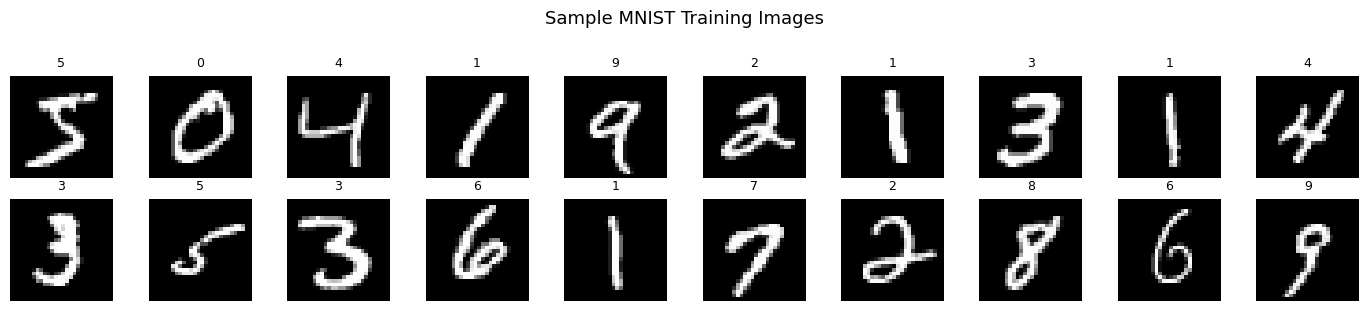

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=9)
    ax.axis('off')
fig.suptitle('Sample MNIST Training Images', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 1 - Variational Autoencoder (VAE)

## 3. Model Architecture

The VAE consists of an **encoder** $q_\phi(z|x)$ and a **decoder** $p_\theta(x|z)$.

### Encoder
Maps input $x \in \mathbb{R}^{784}$ through a hidden layer to produce:
- Mean vector $\mu \in \mathbb{R}^d$
- Log-variance vector $\log \sigma^2 \in \mathbb{R}^d$

### Reparameterization Trick
To allow gradient flow through the stochastic sampling:
$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

where $\sigma = \exp(\frac{1}{2} \log \sigma^2)$.

### Decoder
Maps latent vector $z \in \mathbb{R}^d$ through a hidden layer back to $\hat{x} \in \mathbb{R}^{784}$ with a sigmoid activation (to match $[0,1]$ pixel range).

### Loss Function
The loss is the negative Evidence Lower Bound (ELBO):

$$\mathcal{L} = \underbrace{-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction (BCE)}} + \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{KL Divergence}}$$

For a Gaussian encoder $q_\phi(z|x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$ and standard normal prior $p(z) = \mathcal{N}(0, I)$:

$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

## 3.1 VAE Implementation

In [4]:
class VAE(nn.Module):
    """
    Variational Autoencoder with single hidden layer encoder/decoder.

    Architecture:
        Encoder: x (784) -> h_enc (h_dim) -> mu (z_dim), logvar (z_dim)
        Decoder: z (z_dim) -> h_dec (h_dim) -> x_hat (784)
    """
    def __init__(self, input_dim=784, h_dim=400, z_dim=20):
        super(VAE, self).__init__()

        self.input_dim = input_dim
        self.z_dim = z_dim

        # --- Encoder ---
        self.fc_enc = nn.Linear(input_dim, h_dim)       # input -> hidden
        self.fc_mu  = nn.Linear(h_dim, z_dim)            # hidden -> mean
        self.fc_logvar = nn.Linear(h_dim, z_dim)         # hidden -> log-variance

        # --- Decoder ---
        self.fc_dec = nn.Linear(z_dim, h_dim)            # latent -> hidden
        self.fc_out = nn.Linear(h_dim, input_dim)        # hidden -> output

    def encode(self, x):
        """Encode input x to latent distribution parameters (mu, logvar)."""
        h = F.relu(self.fc_enc(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + sigma * epsilon
        where epsilon ~ N(0, I) and sigma = exp(0.5 * logvar).
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        """Decode latent vector z back to image space."""
        h = F.relu(self.fc_dec(z))
        x_hat = torch.sigmoid(self.fc_out(h))
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

## 3.2 Loss Function

In [5]:
def vae_loss(x, x_hat, mu, logvar):
    """
    VAE loss = Reconstruction loss (BCE) + KL divergence.

    Reconstruction: Binary cross-entropy between input and reconstruction.
    KL divergence:  -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)

    Both terms are summed over dimensions and averaged over the batch.
    """
    # Reconstruction loss (summed over pixels, averaged over batch)
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)

    # KL divergence (summed over latent dims, averaged over batch)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    return recon_loss + kl_loss, recon_loss, kl_loss

## 3.3 Training

In [6]:
def train_vae(model, train_loader, test_loader, epochs=30, lr=1e-3):
    """Train the VAE and track loss components."""
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'test_loss': [],  'test_recon': [],  'test_kl': []
    }

    epoch_pbar = tqdm(range(1, epochs + 1), desc='Training', unit='epoch')

    for epoch in epoch_pbar:
        # --- Train ---
        model.train()
        train_loss_sum, train_recon_sum, train_kl_sum = 0, 0, 0
        n_train = 0

        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}',
                          leave=False, unit='batch')
        for batch_x, _ in batch_pbar:
            batch_x = batch_x.view(-1, 784).to(device)
            x_hat, mu, logvar = model(batch_x)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * batch_x.size(0)
            train_recon_sum += recon.item() * batch_x.size(0)
            train_kl_sum += kl.item() * batch_x.size(0)
            n_train += batch_x.size(0)

            batch_pbar.set_postfix(loss=f'{loss.item():.2f}')

        # --- Evaluate ---
        model.eval()
        test_loss_sum, test_recon_sum, test_kl_sum = 0, 0, 0
        n_test = 0

        with torch.no_grad():
            for batch_x, _ in test_loader:
                batch_x = batch_x.view(-1, 784).to(device)
                x_hat, mu, logvar = model(batch_x)
                loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar)

                test_loss_sum += loss.item() * batch_x.size(0)
                test_recon_sum += recon.item() * batch_x.size(0)
                test_kl_sum += kl.item() * batch_x.size(0)
                n_test += batch_x.size(0)

        # Record
        history['train_loss'].append(train_loss_sum / n_train)
        history['train_recon'].append(train_recon_sum / n_train)
        history['train_kl'].append(train_kl_sum / n_train)
        history['test_loss'].append(test_loss_sum / n_test)
        history['test_recon'].append(test_recon_sum / n_test)
        history['test_kl'].append(test_kl_sum / n_test)

        epoch_pbar.set_postfix(
            train=f"{history['train_loss'][-1]:.2f}",
            test=f"{history['test_loss'][-1]:.2f}",
            recon=f"{history['test_recon'][-1]:.2f}",
            kl=f"{history['test_kl'][-1]:.2f}"
        )

    return history

In [7]:
# Hyperparameters
INPUT_DIM = 784    # 28 * 28
H_DIM     = 400    # hidden layer size
Z_DIM     = 20     # latent dimension
EPOCHS    = 30
LR        = 1e-3

# Initialize and train
vae = VAE(input_dim=INPUT_DIM, h_dim=H_DIM, z_dim=Z_DIM).to(device)
print(f"VAE Parameters: {sum(p.numel() for p in vae.parameters()):,}")
print(f"Architecture: {INPUT_DIM} -> {H_DIM} -> {Z_DIM} (latent) -> {H_DIM} -> {INPUT_DIM}\n")

history_vae = train_vae(vae, train_loader, test_loader, epochs=EPOCHS, lr=LR)

VAE Parameters: 652,824
Architecture: 784 -> 400 -> 20 (latent) -> 400 -> 784



Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 2/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 3/30:   0%|          | 0/469 [00:00<?, ?batch/s]

...

Epoch 26/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 27/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 28/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 29/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 30/30:   0%|          | 0/469 [00:00<?, ?batch/s]

## 3.4 Training Curves

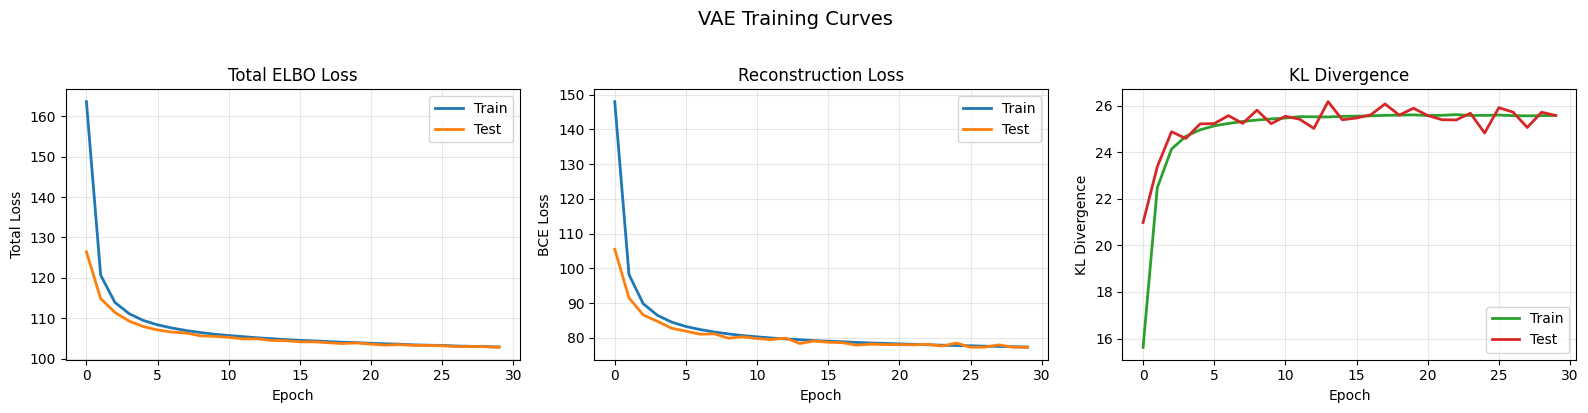

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total loss
axes[0].plot(history_vae['train_loss'], label='Train', linewidth=2)
axes[0].plot(history_vae['test_loss'], label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total ELBO Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history_vae['train_recon'], label='Train', linewidth=2)
axes[1].plot(history_vae['test_recon'], label='Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(history_vae['train_kl'], label='Train', linewidth=2, color='C2')
axes[2].plot(history_vae['test_kl'], label='Test', linewidth=2, color='C3')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('VAE Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.5 Reconstruction Quality

We pass test images through the encoder and decoder to see how well the VAE reconstructs them.

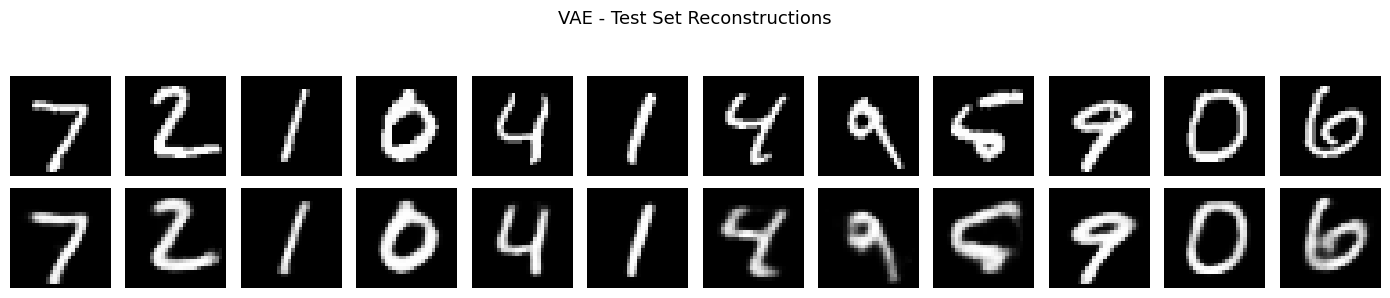

In [9]:
def plot_reconstructions(model, data_loader, n=10, title="VAE Reconstructions"):
    """Show original images (top row) and their reconstructions (bottom row)."""
    model.eval()
    batch_x, batch_y = next(iter(data_loader))
    batch_x = batch_x[:n].to(device)

    with torch.no_grad():
        x_hat, _, _ = model(batch_x.view(-1, 784))

    fig, axes = plt.subplots(2, n, figsize=(14, 3))
    for i in range(n):
        # Original
        axes[0, i].imshow(batch_x[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=11, rotation=0, labelpad=55)

        # Reconstruction
        axes[1, i].imshow(x_hat[i].cpu().view(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Recon', fontsize=11, rotation=0, labelpad=55)

    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

plot_reconstructions(vae, test_loader, n=12, title="VAE - Test Set Reconstructions")

## 3.6 Generating New Samples

We sample random latent vectors $z \sim \mathcal{N}(0, I)$ and pass them through the decoder to generate new digit images. Since the VAE has no conditioning mechanism, the generated digit class is **random**.

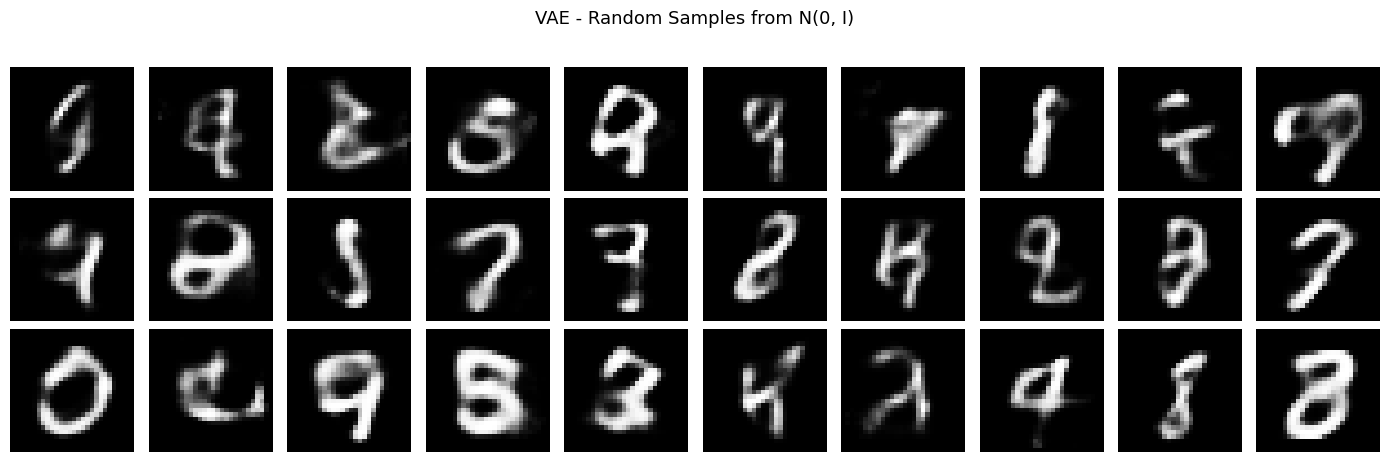

In [10]:
def generate_samples(model, n_samples=20, z_dim=20, title="VAE Generated Samples"):
    """Generate images by sampling z ~ N(0, I) and decoding."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim).to(device)
        samples = model.decode(z).cpu().view(-1, 28, 28)

    n_cols = 10
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 1.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    for i in range(n_rows * n_cols):
        ax = axes[i // n_cols, i % n_cols]
        if i < n_samples:
            ax.imshow(samples[i], cmap='gray')
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

generate_samples(vae, n_samples=30, z_dim=Z_DIM, title="VAE - Random Samples from N(0, I)")

## 3.7 Latent Space Visualization

### 2D Latent Space Traversal

We generate images on a grid by sweeping two latent dimensions through a range of values (using the inverse CDF of the standard normal). This reveals the smooth manifold learned by the VAE.

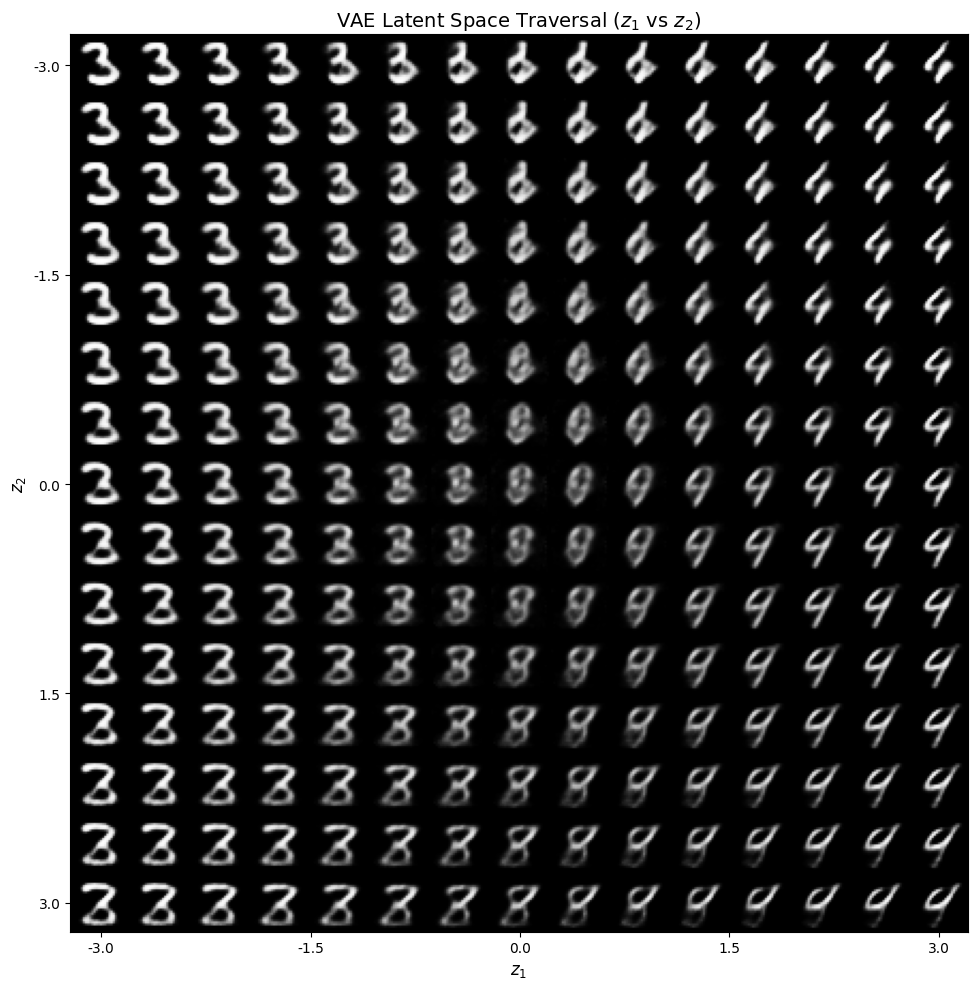

In [11]:
def plot_latent_grid(model, z_dim=20, grid_size=15, z_range=(-3, 3)):
    """
    Generate a grid of images by varying the first two latent dimensions.
    Remaining dimensions are set to 0.
    """
    model.eval()

    # Create grid of z values
    vals = np.linspace(z_range[0], z_range[1], grid_size)

    canvas = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, yi in enumerate(vals):
            for j, xi in enumerate(vals):
                z = torch.zeros(1, z_dim).to(device)
                z[0, 0] = xi
                z[0, 1] = yi
                sample = model.decode(z).cpu().view(28, 28).numpy()
                canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = sample

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap='gray', origin='upper')
    ax.set_xlabel('$z_1$', fontsize=12)
    ax.set_ylabel('$z_2$', fontsize=12)

    # Set tick labels to show actual z values
    tick_pos = np.linspace(14, 28 * grid_size - 14, 5)
    tick_labels = np.linspace(z_range[0], z_range[1], 5)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f'{v:.1f}' for v in tick_labels])
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f'{v:.1f}' for v in tick_labels])

    ax.set_title('VAE Latent Space Traversal ($z_1$ vs $z_2$)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_latent_grid(vae, z_dim=Z_DIM, grid_size=15)

### t-SNE of the Latent Space

We encode test images and visualize the latent representations with t-SNE, colored by digit class. A well-trained VAE should show some clustering by digit identity, though not as sharp as a discriminative model.

Running t-SNE on latent representations...


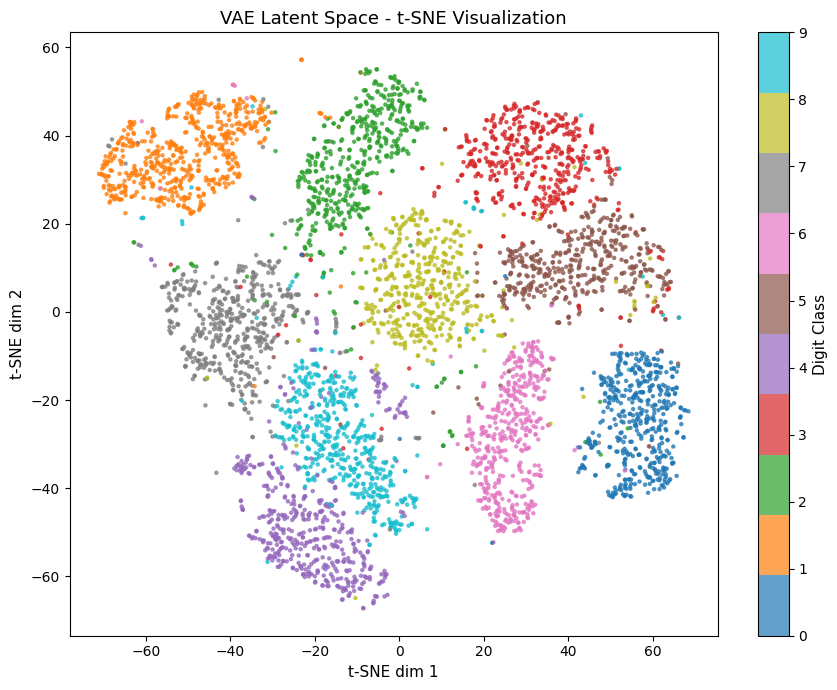

In [12]:
from sklearn.manifold import TSNE

def plot_latent_tsne(model, data_loader, n_points=5000):
    """Encode test images and visualize with t-SNE."""
    model.eval()
    z_all, y_all = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.view(-1, 784).to(device)
            mu, _ = model.encode(batch_x)
            z_all.append(mu.cpu().numpy())
            y_all.append(batch_y.numpy())
            if sum(len(z) for z in z_all) >= n_points:
                break

    z_all = np.concatenate(z_all)[:n_points]
    y_all = np.concatenate(y_all)[:n_points]

    print("Running t-SNE on latent representations...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    z_2d = tsne.fit_transform(z_all)

    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=y_all, cmap='tab10',
                         s=5, alpha=0.7)
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
    cbar.set_label('Digit Class', fontsize=11)
    ax.set_xlabel('t-SNE dim 1', fontsize=11)
    ax.set_ylabel('t-SNE dim 2', fontsize=11)
    ax.set_title('VAE Latent Space - t-SNE Visualization', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_latent_tsne(vae, test_loader)

### Latent Dimension Interpolation

Interpolating between two encoded digits in the latent space shows smooth transitions, demonstrating that the VAE has learned a meaningful, continuous representation.

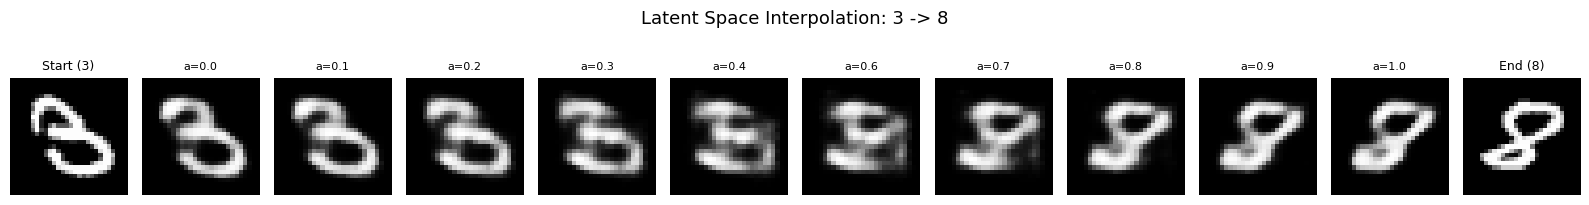

In [13]:
def plot_interpolation(model, data_loader, z_dim=20, n_steps=10):
    """Interpolate between two images in latent space."""
    model.eval()
    batch_x, batch_y = next(iter(data_loader))

    # Find two different digits
    idx_a = (batch_y == 3).nonzero(as_tuple=True)[0][0]
    idx_b = (batch_y == 8).nonzero(as_tuple=True)[0][0]

    x_a = batch_x[idx_a].view(1, 784).to(device)
    x_b = batch_x[idx_b].view(1, 784).to(device)

    with torch.no_grad():
        mu_a, _ = model.encode(x_a)
        mu_b, _ = model.encode(x_b)

        fig, axes = plt.subplots(1, n_steps + 2, figsize=(16, 2))

        # Show original A
        axes[0].imshow(x_a.cpu().view(28, 28), cmap='gray')
        axes[0].set_title('Start (3)', fontsize=9)
        axes[0].axis('off')

        # Interpolations
        for i in range(n_steps):
            alpha = i / (n_steps - 1)
            z_interp = (1 - alpha) * mu_a + alpha * mu_b
            img = model.decode(z_interp).cpu().view(28, 28)
            axes[i + 1].imshow(img, cmap='gray')
            axes[i + 1].set_title(f'a={alpha:.1f}', fontsize=8)
            axes[i + 1].axis('off')

        # Show original B
        axes[-1].imshow(x_b.cpu().view(28, 28), cmap='gray')
        axes[-1].set_title('End (8)', fontsize=9)
        axes[-1].axis('off')

    plt.suptitle('Latent Space Interpolation: 3 -> 8', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

plot_interpolation(vae, test_loader, z_dim=Z_DIM)

---
# Part 2 - Conditional Variational Autoencoder (CVAE)

## 4. Architecture Modifications

The CVAE extends the VAE by conditioning both the encoder and decoder on the class label $y$:

### Encoder
Input is now $[x; \text{onehot}(y)] \in \mathbb{R}^{784 + 10}$, where the one-hot vector is concatenated with the flattened image.

### Decoder
Input is now $[z; \text{onehot}(y)] \in \mathbb{R}^{d + 10}$, where the one-hot label is concatenated with the latent vector.

This allows the model to learn digit-specific latent representations and enables **controlled generation**: we can specify which digit to produce.

## 4.1 CVAE Implementation

In [14]:
class CVAE(nn.Module):
    """
    Conditional Variational Autoencoder.

    Architecture:
        Encoder: [x; onehot(y)] (784+10) -> h_enc (h_dim) -> mu (z_dim), logvar (z_dim)
        Decoder: [z; onehot(y)] (z_dim+10) -> h_dec (h_dim) -> x_hat (784)
    """
    def __init__(self, input_dim=784, h_dim=400, z_dim=20, n_classes=10):
        super(CVAE, self).__init__()

        self.input_dim = input_dim
        self.z_dim = z_dim
        self.n_classes = n_classes

        # --- Encoder: input = x + one-hot label ---
        self.fc_enc = nn.Linear(input_dim + n_classes, h_dim)
        self.fc_mu  = nn.Linear(h_dim, z_dim)
        self.fc_logvar = nn.Linear(h_dim, z_dim)

        # --- Decoder: input = z + one-hot label ---
        self.fc_dec = nn.Linear(z_dim + n_classes, h_dim)
        self.fc_out = nn.Linear(h_dim, input_dim)

    def encode(self, x, y_onehot):
        """Encode x conditioned on y."""
        x_cond = torch.cat([x, y_onehot], dim=1)  # [batch, 784+10]
        h = F.relu(self.fc_enc(x_cond))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, y_onehot):
        """Decode z conditioned on y."""
        z_cond = torch.cat([z, y_onehot], dim=1)  # [batch, z_dim+10]
        h = F.relu(self.fc_dec(z_cond))
        x_hat = torch.sigmoid(self.fc_out(h))
        return x_hat

    def forward(self, x, y_onehot):
        mu, logvar = self.encode(x, y_onehot)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, y_onehot)
        return x_hat, mu, logvar

In [15]:
def to_onehot(labels, n_classes=10):
    """Convert integer labels to one-hot vectors."""
    return F.one_hot(labels, n_classes).float()

## 4.2 Training the CVAE

In [16]:
def train_cvae(model, train_loader, test_loader, epochs=30, lr=1e-3):
    """Train the CVAE and track loss components."""
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'test_loss': [],  'test_recon': [],  'test_kl': []
    }

    epoch_pbar = tqdm(range(1, epochs + 1), desc='Training CVAE', unit='epoch')

    for epoch in epoch_pbar:
        # --- Train ---
        model.train()
        train_loss_sum, train_recon_sum, train_kl_sum = 0, 0, 0
        n_train = 0

        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}',
                          leave=False, unit='batch')
        for batch_x, batch_y in batch_pbar:
            batch_x = batch_x.view(-1, 784).to(device)
            y_onehot = to_onehot(batch_y, 10).to(device)

            x_hat, mu, logvar = model(batch_x, y_onehot)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * batch_x.size(0)
            train_recon_sum += recon.item() * batch_x.size(0)
            train_kl_sum += kl.item() * batch_x.size(0)
            n_train += batch_x.size(0)

            batch_pbar.set_postfix(loss=f'{loss.item():.2f}')

        # --- Evaluate ---
        model.eval()
        test_loss_sum, test_recon_sum, test_kl_sum = 0, 0, 0
        n_test = 0

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.view(-1, 784).to(device)
                y_onehot = to_onehot(batch_y, 10).to(device)

                x_hat, mu, logvar = model(batch_x, y_onehot)
                loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar)

                test_loss_sum += loss.item() * batch_x.size(0)
                test_recon_sum += recon.item() * batch_x.size(0)
                test_kl_sum += kl.item() * batch_x.size(0)
                n_test += batch_x.size(0)

        # Record
        history['train_loss'].append(train_loss_sum / n_train)
        history['train_recon'].append(train_recon_sum / n_train)
        history['train_kl'].append(train_kl_sum / n_train)
        history['test_loss'].append(test_loss_sum / n_test)
        history['test_recon'].append(test_recon_sum / n_test)
        history['test_kl'].append(test_kl_sum / n_test)

        epoch_pbar.set_postfix(
            train=f"{history['train_loss'][-1]:.2f}",
            test=f"{history['test_loss'][-1]:.2f}",
            recon=f"{history['test_recon'][-1]:.2f}",
            kl=f"{history['test_kl'][-1]:.2f}"
        )

    return history

In [17]:
# Initialize and train CVAE
cvae = CVAE(input_dim=INPUT_DIM, h_dim=H_DIM, z_dim=Z_DIM, n_classes=10).to(device)
print(f"CVAE Parameters: {sum(p.numel() for p in cvae.parameters()):,}")
print(f"Encoder input: {INPUT_DIM} + 10 = {INPUT_DIM + 10}")
print(f"Decoder input: {Z_DIM} + 10 = {Z_DIM + 10}\n")

history_cvae = train_cvae(cvae, train_loader, test_loader, epochs=EPOCHS, lr=LR)

CVAE Parameters: 660,824
Encoder input: 784 + 10 = 794
Decoder input: 20 + 10 = 30



Training CVAE:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 2/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 3/30:   0%|          | 0/469 [00:00<?, ?batch/s]

...

Epoch 26/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 27/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 28/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 29/30:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 30/30:   0%|          | 0/469 [00:00<?, ?batch/s]

## 4.3 Training Curves

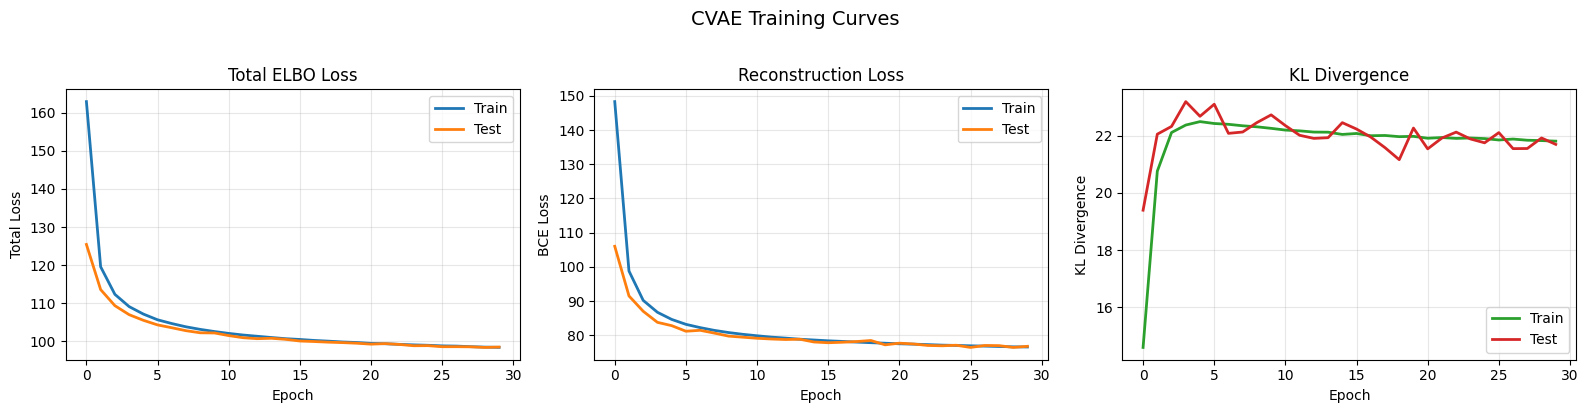

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_cvae['train_loss'], label='Train', linewidth=2)
axes[0].plot(history_cvae['test_loss'], label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total ELBO Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cvae['train_recon'], label='Train', linewidth=2)
axes[1].plot(history_cvae['test_recon'], label='Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_cvae['train_kl'], label='Train', linewidth=2, color='C2')
axes[2].plot(history_cvae['test_kl'], label='Test', linewidth=2, color='C3')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('CVAE Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.4 Conditional Reconstruction

We pass test images through the CVAE along with their true labels to verify reconstruction quality.

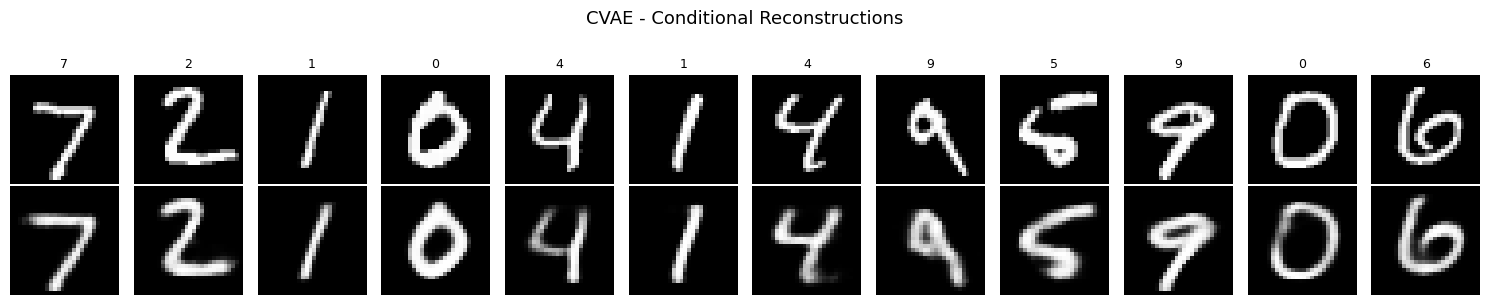

In [19]:
def plot_cvae_reconstructions(model, data_loader, n=12):
    """Show original images (top) and CVAE reconstructions (bottom) with labels."""
    model.eval()
    batch_x, batch_y = next(iter(data_loader))
    batch_x = batch_x[:n].to(device)
    batch_y_oh = to_onehot(batch_y[:n], 10).to(device)

    with torch.no_grad():
        x_hat, _, _ = model(batch_x.view(-1, 784), batch_y_oh)

    fig, axes = plt.subplots(2, n, figsize=(15, 3))
    for i in range(n):
        axes[0, i].imshow(batch_x[i].cpu().squeeze(), cmap='gray')
        axes[0, i].set_title(f'{batch_y[i].item()}', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(x_hat[i].cpu().view(28, 28), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=50)
    axes[1, 0].set_ylabel('Recon', fontsize=10, rotation=0, labelpad=50)
    fig.suptitle('CVAE - Conditional Reconstructions', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

plot_cvae_reconstructions(cvae, test_loader)

## 4.5 Conditional Generation - Specified Digits

This is the key advantage of the CVAE: we can **specify which digit** to generate by providing the one-hot label to the decoder, along with a random latent vector.

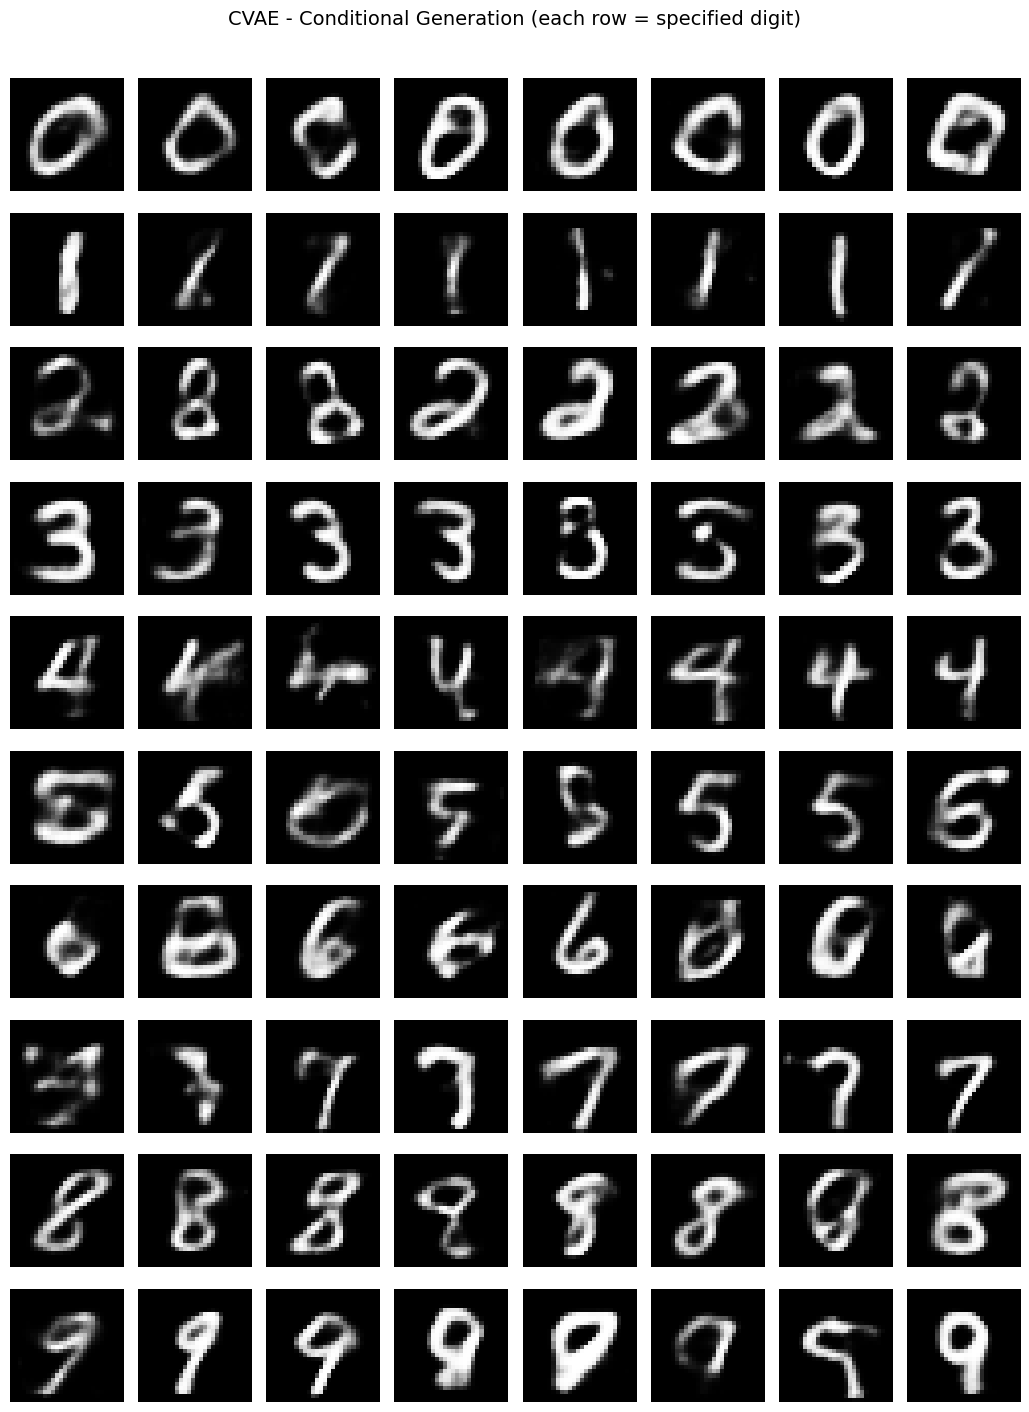

In [20]:
def generate_conditional_samples(model, z_dim=20, n_per_class=8):
    """
    Generate n_per_class samples for each digit 0-9 by conditioning
    the decoder on the one-hot class label.
    """
    model.eval()

    fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class * 1.3, 14))

    with torch.no_grad():
        for digit in range(10):
            z = torch.randn(n_per_class, z_dim).to(device)
            y_onehot = torch.zeros(n_per_class, 10).to(device)
            y_onehot[:, digit] = 1.0

            samples = model.decode(z, y_onehot).cpu().view(-1, 28, 28)

            for j in range(n_per_class):
                axes[digit, j].imshow(samples[j], cmap='gray')
                axes[digit, j].axis('off')

            axes[digit, 0].set_ylabel(f'{digit}', fontsize=13, rotation=0,
                                       labelpad=15, fontweight='bold')

    fig.suptitle('CVAE - Conditional Generation (each row = specified digit)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

generate_conditional_samples(cvae, z_dim=Z_DIM, n_per_class=8)

## 4.6 Style Variation with Fixed Label

For a fixed digit label, different latent samples $z$ produce different **styles** (e.g., slant, thickness, size) of the same digit. This shows the latent space captures intra-class variation.

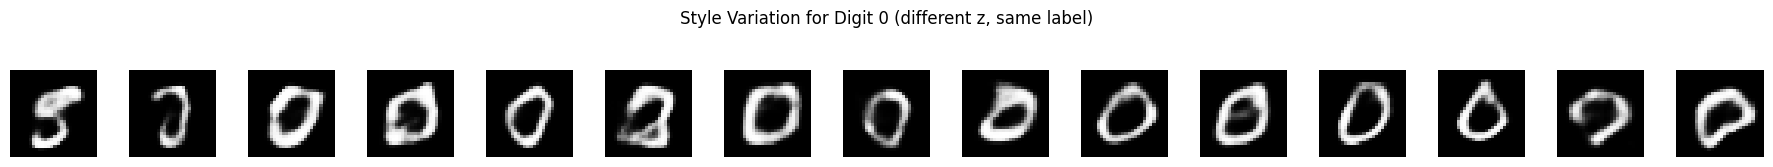

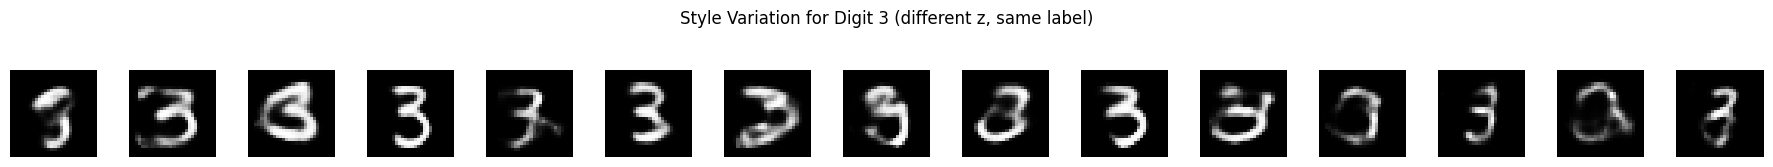

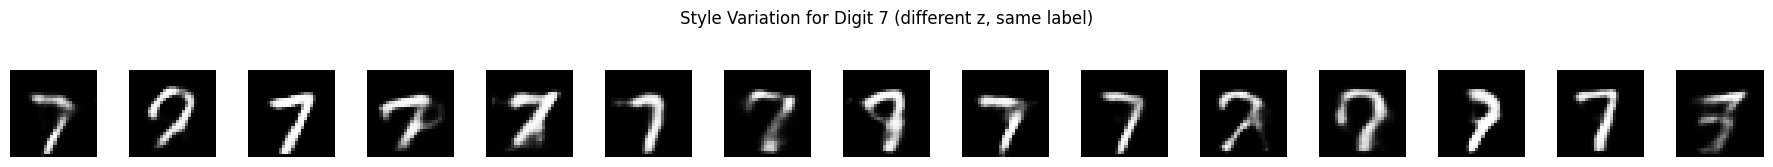

In [21]:
def plot_style_variation(model, digit, z_dim=20, n_samples=15):
    """Show how different z vectors produce different styles of the same digit."""
    model.eval()

    with torch.no_grad():
        z = torch.randn(n_samples, z_dim).to(device)
        y_onehot = torch.zeros(n_samples, 10).to(device)
        y_onehot[:, digit] = 1.0
        samples = model.decode(z, y_onehot).cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.2, 1.5))
    for i in range(n_samples):
        axes[i].imshow(samples[i], cmap='gray')
        axes[i].axis('off')
    fig.suptitle(f'Style Variation for Digit {digit} (different z, same label)',
                 fontsize=12, y=1.08)
    plt.tight_layout()
    plt.show()

for d in [0, 3, 7]:
    plot_style_variation(cvae, digit=d, z_dim=Z_DIM)

## 4.7 Latent Space Visualization - CVAE

Running t-SNE on CVAE latent representations...


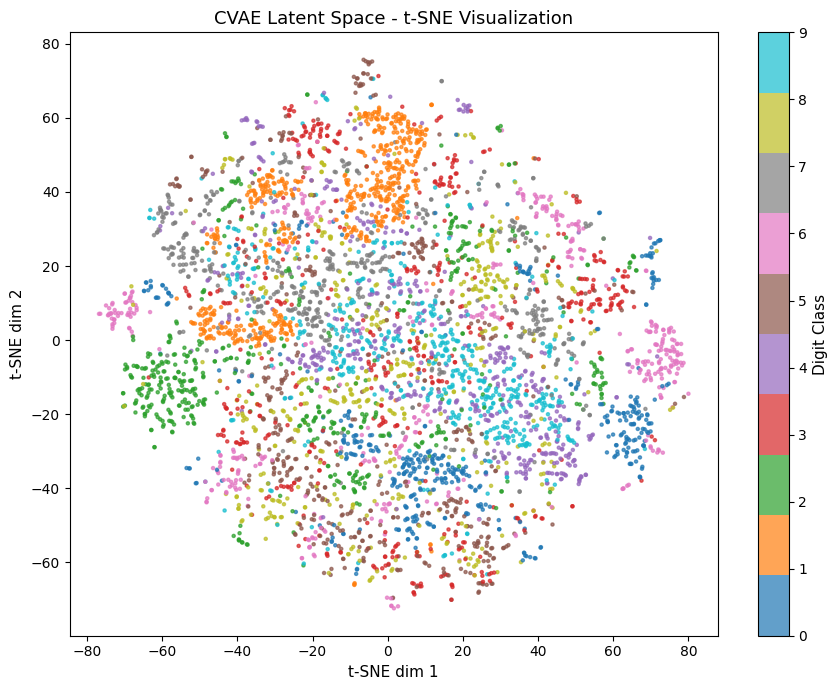

In [22]:
def plot_cvae_latent_tsne(model, data_loader, n_points=5000):
    """Encode test images with CVAE and visualize latent space with t-SNE."""
    model.eval()
    z_all, y_all = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.view(-1, 784).to(device)
            y_onehot = to_onehot(batch_y, 10).to(device)
            mu, _ = model.encode(batch_x, y_onehot)
            z_all.append(mu.cpu().numpy())
            y_all.append(batch_y.numpy())
            if sum(len(z) for z in z_all) >= n_points:
                break

    z_all = np.concatenate(z_all)[:n_points]
    y_all = np.concatenate(y_all)[:n_points]

    print("Running t-SNE on CVAE latent representations...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    z_2d = tsne.fit_transform(z_all)

    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=y_all, cmap='tab10',
                         s=5, alpha=0.7)
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
    cbar.set_label('Digit Class', fontsize=11)
    ax.set_xlabel('t-SNE dim 1', fontsize=11)
    ax.set_ylabel('t-SNE dim 2', fontsize=11)
    ax.set_title('CVAE Latent Space - t-SNE Visualization', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_cvae_latent_tsne(cvae, test_loader)

---
# 5. VAE vs CVAE Comparison

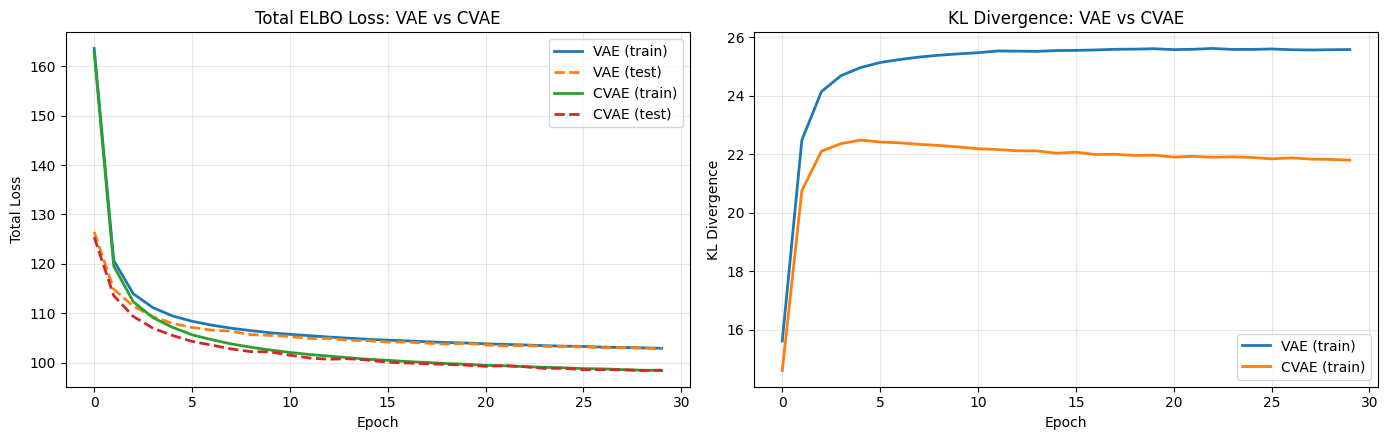

Final Test Loss - VAE:  102.79
Final Test Loss - CVAE: 98.49


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Total loss comparison
axes[0].plot(history_vae['train_loss'], label='VAE (train)', linewidth=2, linestyle='-')
axes[0].plot(history_vae['test_loss'], label='VAE (test)', linewidth=2, linestyle='--')
axes[0].plot(history_cvae['train_loss'], label='CVAE (train)', linewidth=2, linestyle='-')
axes[0].plot(history_cvae['test_loss'], label='CVAE (test)', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total ELBO Loss: VAE vs CVAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KL divergence comparison
axes[1].plot(history_vae['train_kl'], label='VAE (train)', linewidth=2)
axes[1].plot(history_cvae['train_kl'], label='CVAE (train)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_title('KL Divergence: VAE vs CVAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Test Loss - VAE:  {history_vae['test_loss'][-1]:.2f}")
print(f"Final Test Loss - CVAE: {history_cvae['test_loss'][-1]:.2f}")

## 5.1 Side-by-Side Generation Comparison

Comparing random samples from the VAE (uncontrolled digit class) versus the CVAE (controlled digit class).

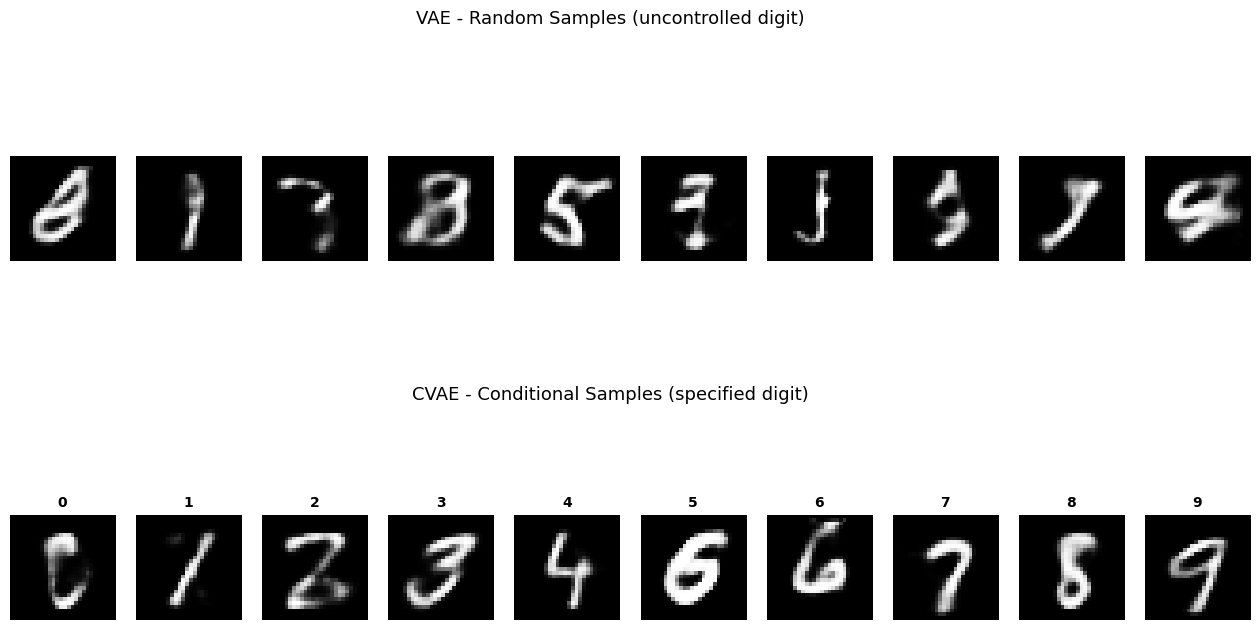

In [24]:
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

# VAE random samples
gs_vae = gs[0].subgridspec(1, 10)
vae.eval()
with torch.no_grad():
    z = torch.randn(10, Z_DIM).to(device)
    vae_samples = vae.decode(z).cpu().view(-1, 28, 28)

for i in range(10):
    ax = fig.add_subplot(gs_vae[0, i])
    ax.imshow(vae_samples[i], cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('VAE', fontsize=12, rotation=0, labelpad=30)

fig.text(0.5, 0.95, 'VAE - Random Samples (uncontrolled digit)',
         ha='center', fontsize=13)

# CVAE controlled samples (one of each digit)
gs_cvae = gs[1].subgridspec(1, 10)
cvae.eval()
with torch.no_grad():
    z = torch.randn(10, Z_DIM).to(device)
    labels = torch.arange(10)
    y_oh = to_onehot(labels, 10).to(device)
    cvae_samples = cvae.decode(z, y_oh).cpu().view(-1, 28, 28)

for i in range(10):
    ax = fig.add_subplot(gs_cvae[0, i])
    ax.imshow(cvae_samples[i], cmap='gray')
    ax.set_title(f'{i}', fontsize=10, fontweight='bold')
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('CVAE', fontsize=12, rotation=0, labelpad=30)

fig.text(0.5, 0.48, 'CVAE - Conditional Samples (specified digit)',
         ha='center', fontsize=13)

plt.show()

---
# 6. Hyperparameter Ablations

## 6.1 Effect of Latent Dimension $d$

We train VAEs with different latent dimensions to study the capacity-regularization tradeoff. Larger $d$ allows richer representations but may make the KL term harder to optimize.

In [25]:
z_dims_to_test = [2, 5, 10, 20, 50]
ablation_results = {}

for z_d in z_dims_to_test:
    print(f"\n{'='*50}")
    print(f"  Training VAE with z_dim = {z_d}")
    print(f"{'='*50}")
    model_abl = VAE(input_dim=784, h_dim=400, z_dim=z_d).to(device)
    hist = train_vae(model_abl, train_loader, test_loader, epochs=20, lr=1e-3)
    ablation_results[z_d] = {
        'history': hist,
        'model': model_abl
    }


  Training VAE with z_dim = 2


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 2/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 3/20:   0%|          | 0/469 [00:00<?, ?batch/s]

...

Epoch 16/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 17/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 18/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 19/20:   0%|          | 0/469 [00:00<?, ?batch/s]

Epoch 20/20:   0%|          | 0/469 [00:00<?, ?batch/s]

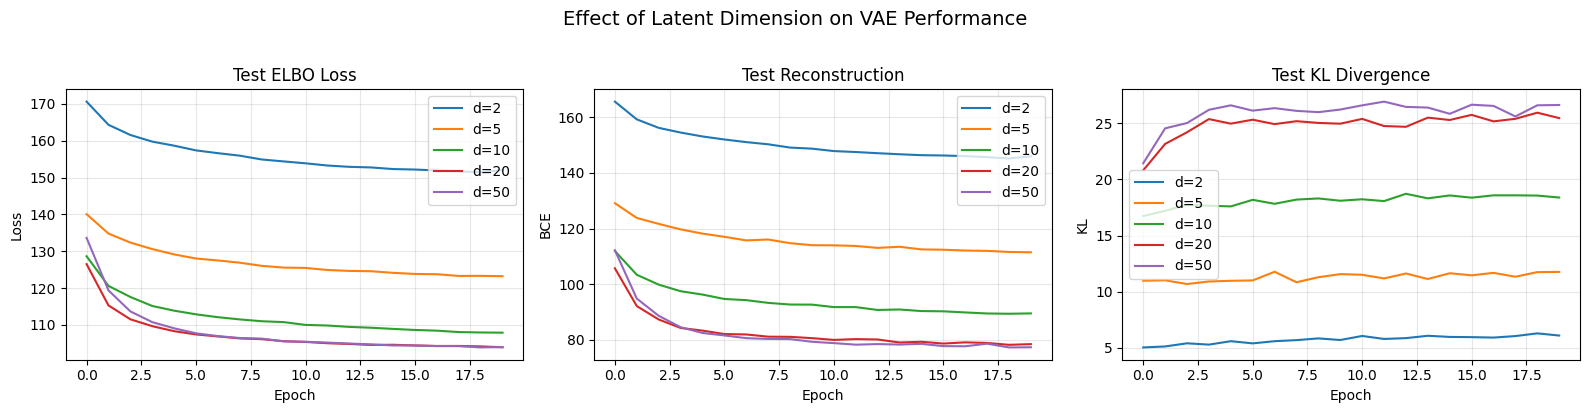

 z_dim |  Test Loss |      Recon |         KL
--------------------------------------------------
     2 |     152.04 |     145.94 |       6.10
     5 |     123.23 |     111.46 |      11.77
    10 |     107.90 |      89.51 |      18.39
    20 |     103.94 |      78.47 |      25.47
    50 |     103.98 |      77.34 |      26.64


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for z_d in z_dims_to_test:
    h = ablation_results[z_d]['history']
    axes[0].plot(h['test_loss'], label=f'd={z_d}', linewidth=1.5)
    axes[1].plot(h['test_recon'], label=f'd={z_d}', linewidth=1.5)
    axes[2].plot(h['test_kl'], label=f'd={z_d}', linewidth=1.5)

for i, (title, ylabel) in enumerate([
    ('Test ELBO Loss', 'Loss'),
    ('Test Reconstruction', 'BCE'),
    ('Test KL Divergence', 'KL')
]):
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel(ylabel)
    axes[i].set_title(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Effect of Latent Dimension on VAE Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'z_dim':>6} | {'Test Loss':>10} | {'Recon':>10} | {'KL':>10}")
print("-" * 50)
for z_d in z_dims_to_test:
    h = ablation_results[z_d]['history']
    print(f"{z_d:>6} | {h['test_loss'][-1]:>10.2f} | {h['test_recon'][-1]:>10.2f} | {h['test_kl'][-1]:>10.2f}")

### Generated Samples at Different Latent Dimensions

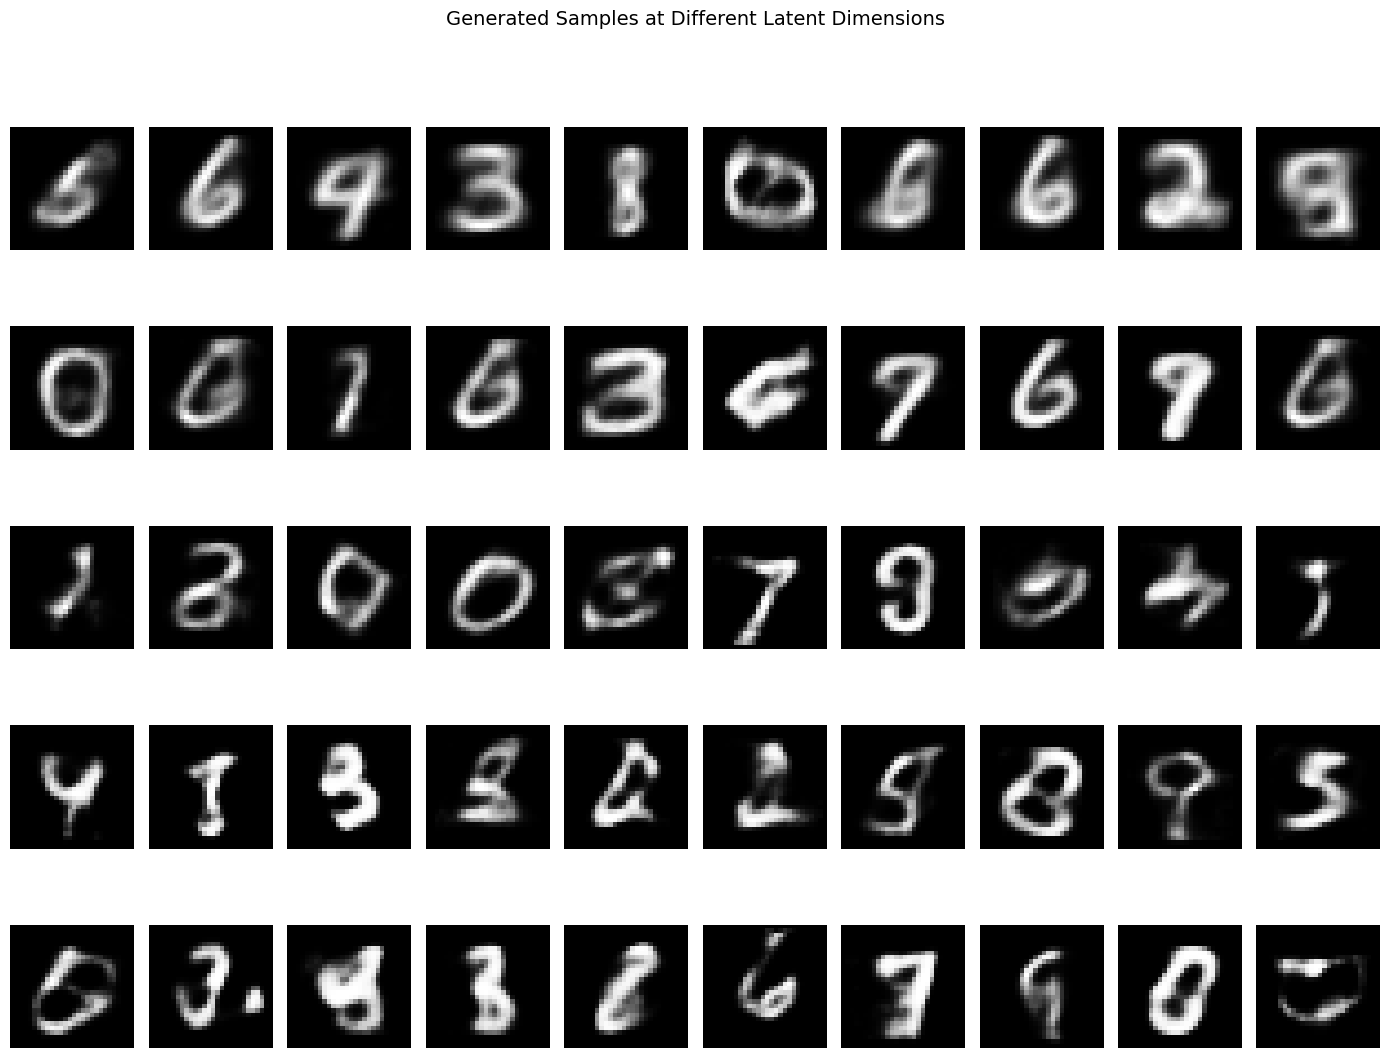

In [27]:
fig, axes = plt.subplots(len(z_dims_to_test), 10, figsize=(14, 2.2 * len(z_dims_to_test)))

for row, z_d in enumerate(z_dims_to_test):
    model_abl = ablation_results[z_d]['model']
    model_abl.eval()
    with torch.no_grad():
        z = torch.randn(10, z_d).to(device)
        samples = model_abl.decode(z).cpu().view(-1, 28, 28)

    for col in range(10):
        axes[row, col].imshow(samples[col], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'd={z_d}', fontsize=11, rotation=0, labelpad=30)

fig.suptitle('Generated Samples at Different Latent Dimensions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6.2 2D Latent Space (Special Case: d=2)

When $d = 2$, we can directly visualize the latent space without t-SNE. This gives us a clear picture of how the VAE organizes digit classes in its learned representation.

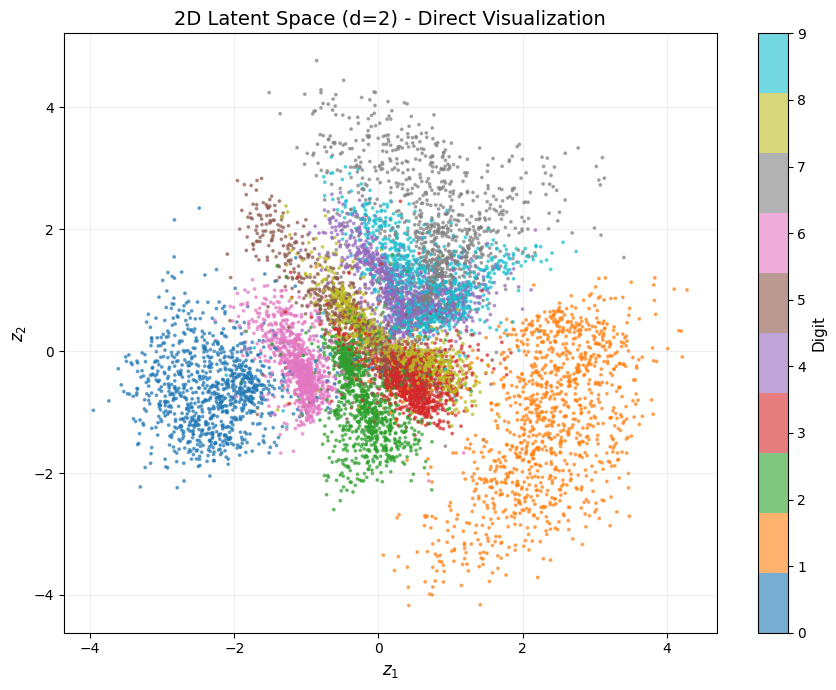

In [28]:
# Visualize the 2D latent space directly
model_2d = ablation_results[2]['model']
model_2d.eval()

z_all, y_all = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.view(-1, 784).to(device)
        mu, _ = model_2d.encode(batch_x)
        z_all.append(mu.cpu().numpy())
        y_all.append(batch_y.numpy())

z_all = np.concatenate(z_all)
y_all = np.concatenate(y_all)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(z_all[:, 0], z_all[:, 1], c=y_all, cmap='tab10',
                     s=3, alpha=0.6)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit', fontsize=11)
ax.set_xlabel('$z_1$', fontsize=12)
ax.set_ylabel('$z_2$', fontsize=12)
ax.set_title('2D Latent Space (d=2) - Direct Visualization', fontsize=14)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

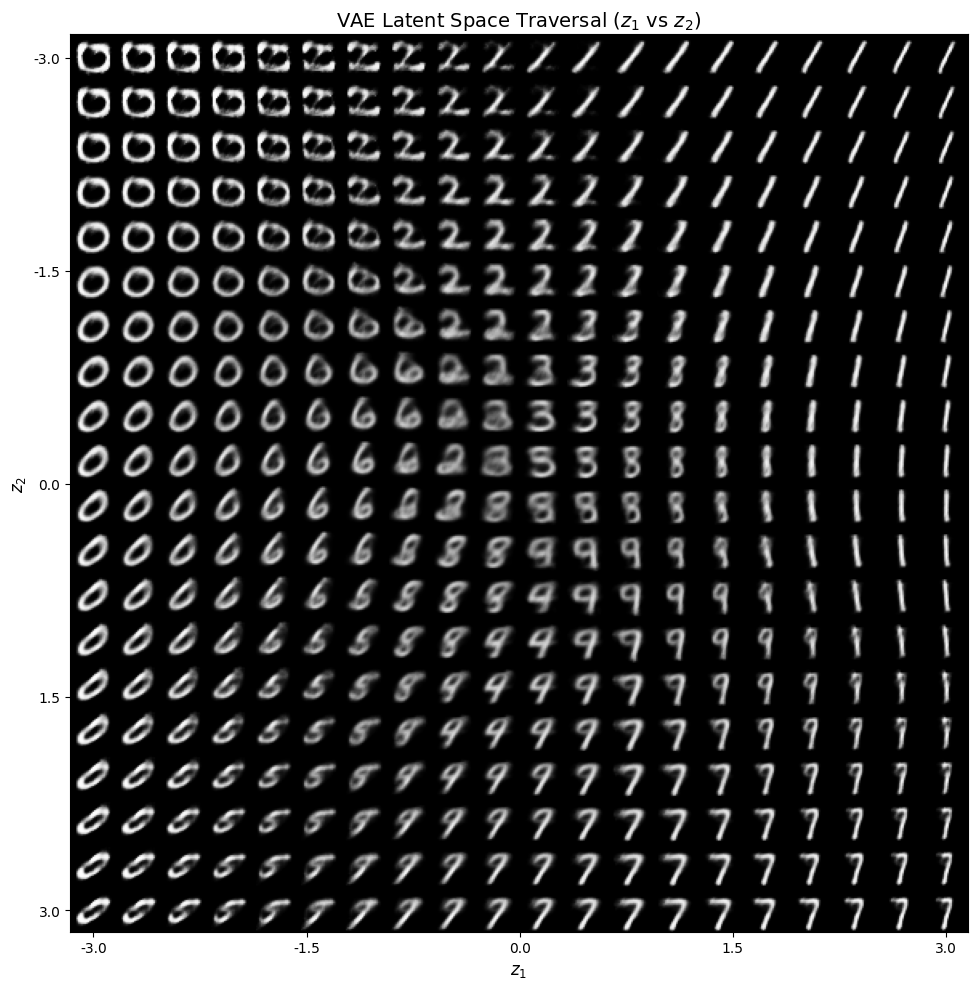

In [29]:
# Generate a manifold from the 2D latent space
plot_latent_grid(model_2d, z_dim=2, grid_size=20, z_range=(-3, 3))

---
# 7. Summary & Key Observations

### VAE (Part 1)
- The VAE successfully learns to reconstruct MNIST digits and generate plausible new samples from random latent vectors.
- The latent space is smooth and continuous: interpolation between encoded digits produces gradual transitions.
- t-SNE visualization shows partial clustering by digit class, though without explicit conditioning the clusters are not perfectly separated.
- Random generation produces digits of **uncontrolled** class identity.

### CVAE (Part 2)
- By conditioning on the class label (one-hot vector), the CVAE can generate **specific requested digits**.
- Reconstruction quality is comparable to the VAE (slightly better, since the label provides additional information to the decoder).
- Different latent samples with the same label produce varied *styles* (thickness, slant, size) of the same digit.
- The CVAE disentangles digit identity (captured by the label) from style (captured by $z$).

### Ablation Insights
- **Latent dimension**: $d = 2$ is too small for sharp reconstructions but enables direct visualization. $d = 20$ provides a good balance. Larger $d$ gives marginal improvement with diminishing returns.
- **KL vs Reconstruction tradeoff**: Smaller $d$ forces higher KL (the prior is more constraining), while larger $d$ makes it easier to match the prior but can lead to posterior collapse if not tuned carefully.